In [1]:
%load_ext autoreload
%autoreload 

In [4]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
# Import python package for working with cooler files and tools for analysis
import cooler
import cooltools.lib.plotting
from cooltools import insulation

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.4'):
    raise AssertionError("tutorials rely on cooltools version 0.5.4 or higher,"+
                         "please check your cooltools version and update to the latest")

In [7]:
import cooler
#from cooltools.insulation import insulation
resolution = 10000
# Load Coolers with the specified resolution dynamically using f-strings
clr_1 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/{resolution}")
clr_2 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/{resolution}")
# Define window sizes as multiples of the resolution
windows = [3*resolution, 5*resolution, 10*resolution, 25*resolution]
# Run insulation analysis
insulation_table_1 = insulation(clr_1, windows, verbose=True)
insulation_table_2 = insulation(clr_2, windows, verbose=True)

INFO:root:fallback to serial implementation.
INFO:root:Processing region chr1
INFO:root:Processing region chr2
INFO:root:Processing region chr3
INFO:root:Processing region chr4
INFO:root:Processing region chr5
INFO:root:Processing region chr6
INFO:root:Processing region chr7
INFO:root:Processing region chr8
INFO:root:Processing region chr9
INFO:root:Processing region chr10
INFO:root:Processing region chr11
INFO:root:Processing region chr12
INFO:root:Processing region chr13
INFO:root:Processing region chr14
INFO:root:Processing region chr15
INFO:root:Processing region chr16
INFO:root:Processing region chr17
INFO:root:Processing region chr18
INFO:root:Processing region chr19
INFO:root:Processing region chr20
INFO:root:Processing region chr21
INFO:root:Processing region chr22
INFO:root:Processing region chrX
INFO:root:Processing region chrY
INFO:root:Processing region chrM
INFO:root:fallback to serial implementation.
INFO:root:Processing region chr1
INFO:root:Processing region chr2
INFO:r

In [8]:
first_window_summary =insulation_table_1.columns[[ str(windows[-1]) in i for i in insulation_table_1.columns]]

insulation_table_1[['chrom','start','end','region','is_bad_bin']+list(first_window_summary)].iloc[1000:1005]

,chrom,start,end,region,is_bad_bin,log2_insulation_score_250000,n_valid_pixels_250000,boundary_strength_250000,is_boundary_250000
1000,chr1,10000000,10010000,chr1,False,0.361939,622.0,NaN,False
1001,chr1,10010000,10020000,chr1,False,0.359204,622.0,NaN,False
1002,chr1,10020000,10030000,chr1,False,0.352685,622.0,0.009254,False
1003,chr1,10030000,10040000,chr1,False,0.360673,622.0,NaN,False
1004,chr1,10040000,10050000,chr1,False,0.369116,622.0,NaN,False


In [9]:
# Functions to help with plotting
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, *args, **kwargs):
    start_pos_vector = [start+resolution*i for i in range(len(matrix_c)+1)]
    import itertools
    n = matrix_c.shape[0]
    t = np.array([[1, 0.5], [-1, 0.5]])
    matrix_a = np.dot(np.array([(i[1], i[0])
                                for i in itertools.product(start_pos_vector[::-1],
                                                           start_pos_vector)]), t)
    x = matrix_a[:, 1].reshape(n + 1, n + 1)
    y = matrix_a[:, 0].reshape(n + 1, n + 1)
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), *args, **kwargs)
    im.set_rasterized(True)
    return im

from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')
def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

(10500000.0, 13200000.0)

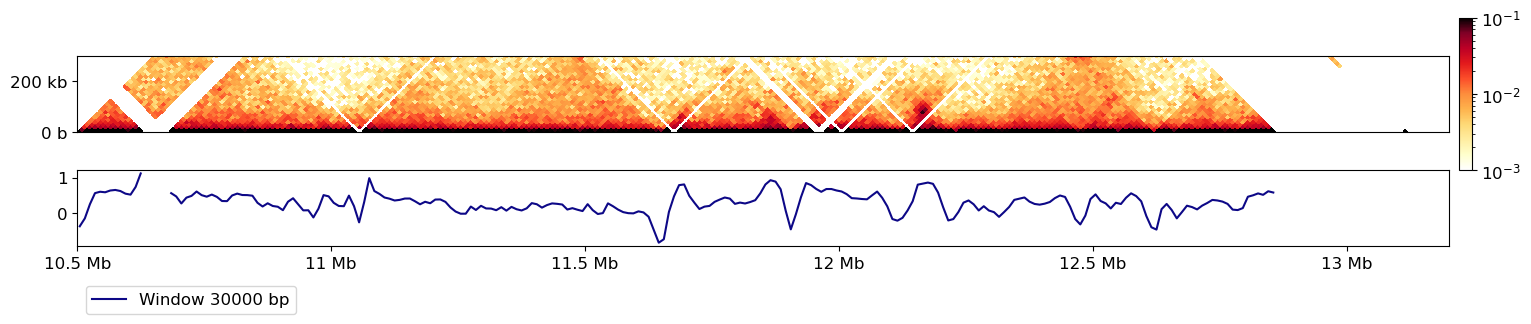

In [14]:
#chr 1
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
plt.rcParams['font.size'] = 12

start = 10_500_000
end = start+ 90*windows[0]
region = ('chr1', start, end)
norm = LogNorm(vmax=0.1, vmin=0.001)
data = clr_1.matrix(balance=True).fetch(region)
f, ax = plt.subplots(figsize=(18, 6))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 10*windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table_1, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)
ins_ax.set_prop_cycle(plt.cycler("color", plt.cm.plasma(np.linspace(0,1,5))))
ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region['log2_insulation_score_'+str(windows[0])],
            label=f'Window {windows[0]} bp')

ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

(10500000.0, 13200000.0)

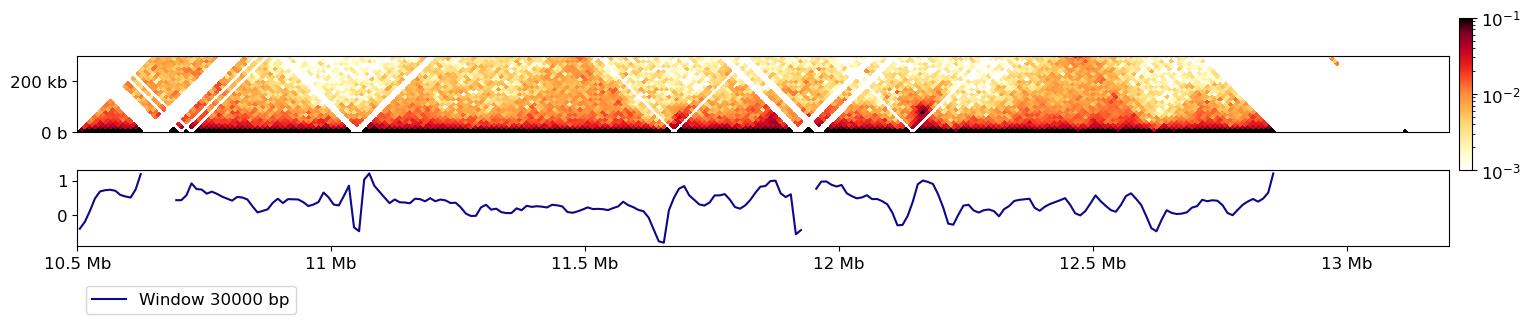

In [12]:
#chr 1
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
plt.rcParams['font.size'] = 12

start = 10_500_000
end = start+ 90*windows[0]
region = ('chr1', start, end)
norm = LogNorm(vmax=0.1, vmin=0.001)
data = clr_2.matrix(balance=True).fetch(region)
f, ax = plt.subplots(figsize=(18, 6))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 10*windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table_2, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)
ins_ax.set_prop_cycle(plt.cycler("color", plt.cm.plasma(np.linspace(0,1,5))))
ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region['log2_insulation_score_'+str(windows[0])],
            label=f'Window {windows[0]} bp')

ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

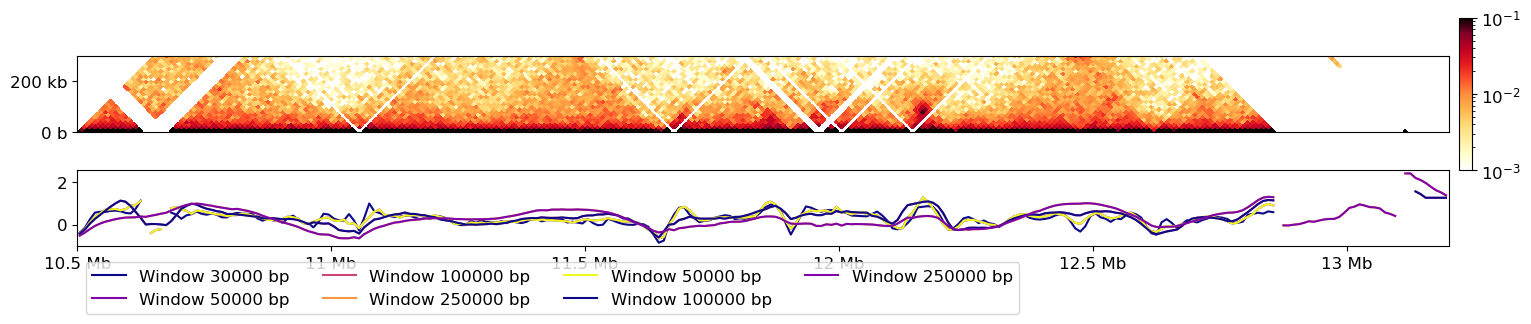

In [16]:
# chr1
for res in windows[1:]:
    ins_ax.plot(insul_region[['start', 'end']].mean(axis=1), insul_region[f'log2_insulation_score_{res}'], label=f'Window {res} bp')
ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);
f

In [17]:
#why many windows? check again

In [20]:
# boundary calling

(10500000.0, 13200000.0)

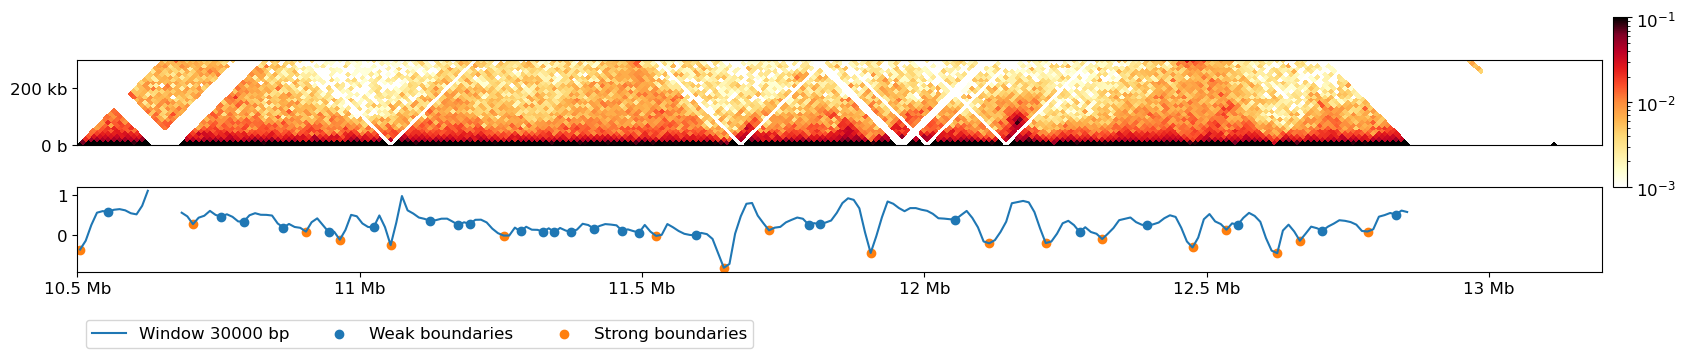

In [18]:
f, ax = plt.subplots(figsize=(20, 10))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 10*windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table_1, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)

ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region[f'log2_insulation_score_{windows[0]}'], label=f'Window {windows[0]} bp')

boundaries = insul_region[~np.isnan(insul_region[f'boundary_strength_{windows[0]}'])]
weak_boundaries = boundaries[~boundaries[f'is_boundary_{windows[0]}']]
strong_boundaries = boundaries[boundaries[f'is_boundary_{windows[0]}']]
ins_ax.scatter(weak_boundaries[['start', 'end']].mean(axis=1),
            weak_boundaries[f'log2_insulation_score_{windows[0]}'], label='Weak boundaries')
ins_ax.scatter(strong_boundaries[['start', 'end']].mean(axis=1),
            strong_boundaries[f'log2_insulation_score_{windows[0]}'], label='Strong boundaries')

ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

(10500000.0, 13200000.0)

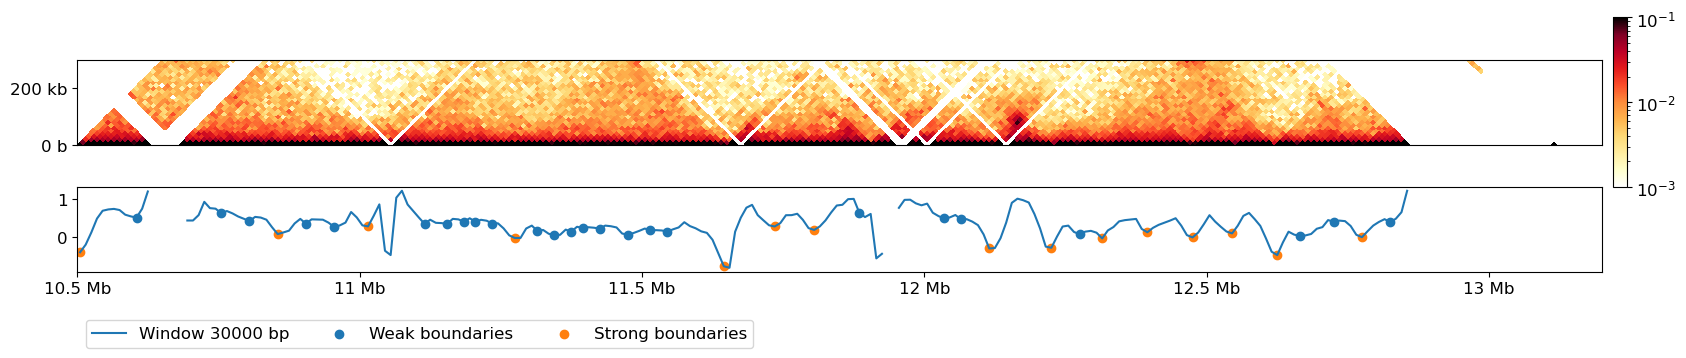

In [19]:
f, ax = plt.subplots(figsize=(20, 10))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 10*windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table_2, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)

ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region[f'log2_insulation_score_{windows[0]}'], label=f'Window {windows[0]} bp')

boundaries = insul_region[~np.isnan(insul_region[f'boundary_strength_{windows[0]}'])]
weak_boundaries = boundaries[~boundaries[f'is_boundary_{windows[0]}']]
strong_boundaries = boundaries[boundaries[f'is_boundary_{windows[0]}']]
ins_ax.scatter(weak_boundaries[['start', 'end']].mean(axis=1),
            weak_boundaries[f'log2_insulation_score_{windows[0]}'], label='Weak boundaries')
ins_ax.scatter(strong_boundaries[['start', 'end']].mean(axis=1),
            strong_boundaries[f'log2_insulation_score_{windows[0]}'], label='Strong boundaries')

ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

In [21]:
# boundary strength

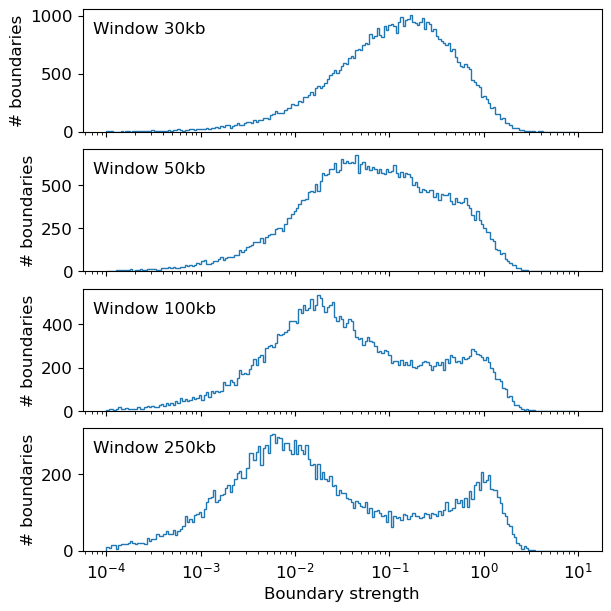

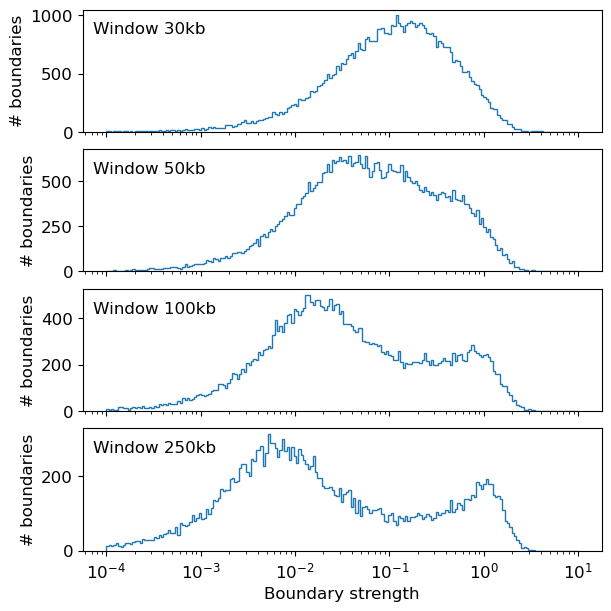

In [22]:
histkwargs = dict(
    bins=10**np.linspace(-4,1,200),
    histtype='step',
    lw=2,
)

f, axs = plt.subplots(len(windows),1, sharex=True, figsize=(6,6), constrained_layout=True)
for i, (w, ax) in enumerate(zip(windows, axs)):
    ax.hist(
        insulation_table_1[f'boundary_strength_{w}'],
        **histkwargs
    )
    ax.text(0.02, 0.9,
             f'Window {w//1000}kb',
             ha='left',
             va='top',
             transform=ax.transAxes)

    ax.set(
        xscale='log',
        ylabel='# boundaries'
    )

axs[-1].set(xlabel='Boundary strength');

###

histkwargs = dict(
    bins=10**np.linspace(-4,1,200),
    histtype='step',
    lw=2,
)

f, axs = plt.subplots(len(windows),1, sharex=True, figsize=(6,6), constrained_layout=True)
for i, (w, ax) in enumerate(zip(windows, axs)):
    ax.hist(
        insulation_table_2[f'boundary_strength_{w}'],
        **histkwargs
    )
    ax.text(0.02, 0.9,
             f'Window {w//1000}kb',
             ha='left',
             va='top',
             transform=ax.transAxes)

    ax.set(
        xscale='log',
        ylabel='# boundaries'
    )

axs[-1].set(xlabel='Boundary strength');


[Text(0.5, 0, 'Boundary strength')]

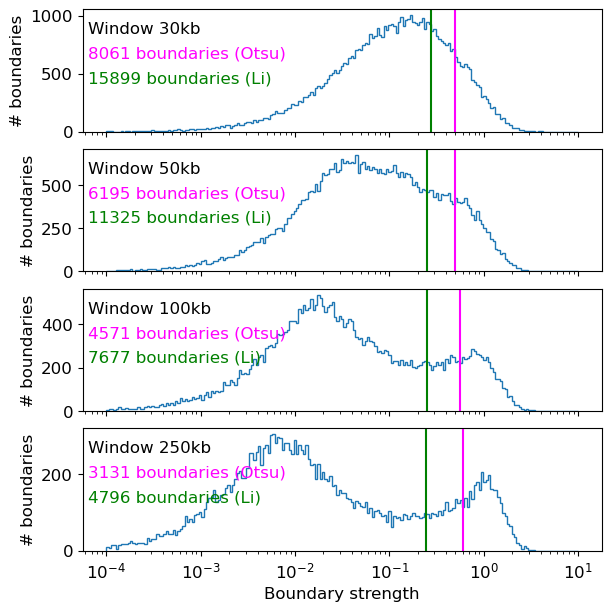

In [38]:
from skimage.filters import threshold_li, threshold_otsu

f, axs = plt.subplots(len(windows), 1, sharex=True, figsize=(6,6), constrained_layout=True)
thresholds_li_1 = {}
thresholds_otsu_1 = {}
for i, (w, ax) in enumerate(zip(windows, axs)):
    ax.hist(
        insulation_table_1[f'boundary_strength_{w}'],
        **histkwargs
    )
    thresholds_li_1[w] = threshold_li(insulation_table_1[f'boundary_strength_{w}'].dropna().values)
    thresholds_otsu_1[w] = threshold_otsu(insulation_table_1[f'boundary_strength_{w}'].dropna().values)
    n_boundaries_li = (insulation_table_1[f'boundary_strength_{w}'].dropna()>=thresholds_li_1[w]).sum()
    n_boundaries_otsu = (insulation_table_1[f'boundary_strength_{w}'].dropna()>=thresholds_otsu_1[w]).sum()
    ax.axvline(thresholds_li_1[w], c='green')
    ax.axvline(thresholds_otsu_1[w], c='magenta')
    ax.text(0.01, 0.9,
             f'Window {w//1000}kb',
             ha='left',
             va='top',
             transform=ax.transAxes)
    ax.text(0.01, 0.7,
            f'{n_boundaries_otsu} boundaries (Otsu)',
            c='magenta',
            ha='left',
            va='top',
            transform=ax.transAxes)
    ax.text(0.01, 0.5,
            f'{n_boundaries_li} boundaries (Li)',
            c='green',
            ha='left',
            va='top',
            transform=ax.transAxes)

    ax.set(
        xscale='log',
        ylabel='# boundaries'
    )

axs[-1].set(xlabel='Boundary strength')

[Text(0.5, 0, 'Boundary strength')]

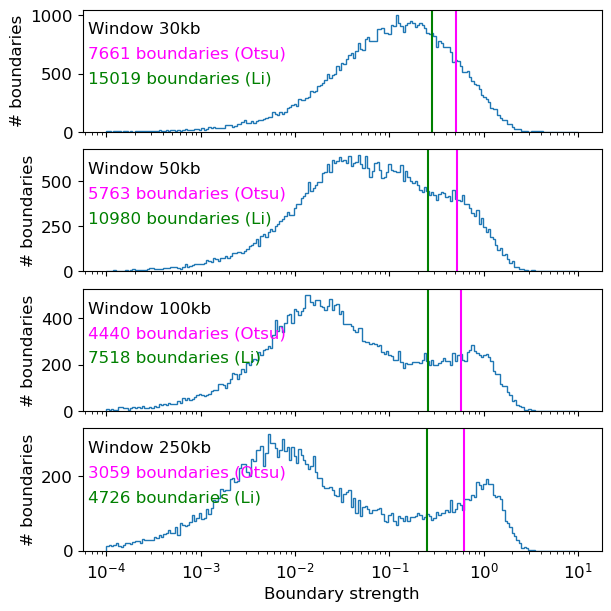

In [39]:
from skimage.filters import threshold_li, threshold_otsu

f, axs = plt.subplots(len(windows), 1, sharex=True, figsize=(6,6), constrained_layout=True)
thresholds_li_2 = {}
thresholds_otsu_2 = {}
for i, (w, ax) in enumerate(zip(windows, axs)):
    ax.hist(
        insulation_table_2[f'boundary_strength_{w}'],
        **histkwargs
    )
    thresholds_li_2[w] = threshold_li(insulation_table_2[f'boundary_strength_{w}'].dropna().values)
    thresholds_otsu_2[w] = threshold_otsu(insulation_table_2[f'boundary_strength_{w}'].dropna().values)
    n_boundaries_li = (insulation_table_2[f'boundary_strength_{w}'].dropna()>=thresholds_li_2[w]).sum()
    n_boundaries_otsu = (insulation_table_2[f'boundary_strength_{w}'].dropna()>=thresholds_otsu_2[w]).sum()
    ax.axvline(thresholds_li_2[w], c='green')
    ax.axvline(thresholds_otsu_2[w], c='magenta')
    ax.text(0.01, 0.9,
             f'Window {w//1000}kb',
             ha='left',
             va='top',
             transform=ax.transAxes)
    ax.text(0.01, 0.7,
            f'{n_boundaries_otsu} boundaries (Otsu)',
            c='magenta',
            ha='left',
            va='top',
            transform=ax.transAxes)
    ax.text(0.01, 0.5,
            f'{n_boundaries_li} boundaries (Li)',
            c='green',
            ha='left',
            va='top',
            transform=ax.transAxes)

    ax.set(
        xscale='log',
        ylabel='# boundaries'
    )

axs[-1].set(xlabel='Boundary strength')

In [23]:
#CTCF enrichment at boundaries

In [26]:
# Download test data. The file size is 592 Mb, so the download might take a while:
ctcf_fc_file = cooltools.download_data("HFF_CTCF_fc", cache=True, data_dir="/usr/users/papantonis1/aman/microc_project/refgen")

Test dataset HFF_CTCF_fc (file test_CTCF.bigWig) is not in the cache directory /usr/users/papantonis1/aman/microc_project/refgen/
downloading: https://osf.io/w92u3/download as /usr/users/papantonis1/aman/microc_project/refgen/test_CTCF.bigWig


In [28]:
import bbi

In [33]:
is_boundary_1 = np.any([
        ~insulation_table_1[f'boundary_strength_{w}'].isnull()
        for w in windows],
    axis=0)
boundaries_1 = insulation_table_1[is_boundary_1]

###

is_boundary_2 = np.any([
        ~insulation_table_2[f'boundary_strength_{w}'].isnull()
        for w in windows],
    axis=0)
boundaries_2 = insulation_table_2[is_boundary_2]

In [31]:
boundaries_1.head()

,chrom,start,end,region,is_bad_bin,log2_insulation_score_30000,n_valid_pixels_30000,log2_insulation_score_50000,n_valid_pixels_50000,log2_insulation_score_100000,...,log2_insulation_score_250000,n_valid_pixels_250000,boundary_strength_30000,boundary_strength_50000,boundary_strength_250000,boundary_strength_100000,is_boundary_30000,is_boundary_50000,is_boundary_100000,is_boundary_250000
184,chr1,1840000,1850000,chr1,False,1.644557,6.0,1.995661,22.0,2.852453,...,3.367644,46.0,0.096640,0.027413,NaN,NaN,False,False,False,False
381,chr1,3810000,3820000,chr1,False,0.674545,6.0,0.927948,12.0,0.712073,...,0.577996,197.0,0.187699,NaN,NaN,NaN,False,False,False,False
385,chr1,3850000,3860000,chr1,False,0.393272,6.0,0.412494,22.0,0.316569,...,0.220996,297.0,NaN,0.010367,NaN,NaN,False,False,False,False
386,chr1,3860000,3870000,chr1,False,0.351857,6.0,0.422861,22.0,0.225230,...,0.117156,322.0,0.341736,NaN,NaN,NaN,True,False,False,False
390,chr1,3900000,3910000,chr1,False,-0.794789,6.0,-0.539286,22.0,-0.576300,...,-0.260125,397.0,2.145476,1.785619,NaN,1.160416,True,True,True,False


In [32]:
boundaries_2.head()

,chrom,start,end,region,is_bad_bin,log2_insulation_score_30000,n_valid_pixels_30000,log2_insulation_score_50000,n_valid_pixels_50000,log2_insulation_score_100000,...,log2_insulation_score_250000,n_valid_pixels_250000,boundary_strength_30000,boundary_strength_50000,boundary_strength_250000,boundary_strength_100000,is_boundary_30000,is_boundary_50000,is_boundary_100000,is_boundary_250000
297,chr1,2970000,2980000,chr1,True,1.610320,4.0,2.110118,6.0,2.499777,...,2.984804,21.0,0.060484,NaN,NaN,NaN,False,False,False,False
381,chr1,3810000,3820000,chr1,False,0.746133,6.0,1.106863,12.0,0.797176,...,0.708768,172.0,0.175936,NaN,NaN,NaN,False,False,False,False
385,chr1,3850000,3860000,chr1,False,0.351355,6.0,0.545637,22.0,0.410698,...,0.298830,272.0,0.439925,0.011504,NaN,NaN,True,False,False,False
390,chr1,3900000,3910000,chr1,False,-0.735763,6.0,-0.528542,22.0,-0.513708,...,-0.236776,372.0,2.108168,2.185622,NaN,1.135392,True,True,True,False
396,chr1,3960000,3970000,chr1,False,0.139096,6.0,0.173500,22.0,0.029536,...,-0.069784,522.0,0.022469,NaN,NaN,NaN,False,False,False,False


In [43]:
# Calculate the average ChIP singal/input in the 3kb region around the boundary.
data_dir="/usr/users/papantonis1/aman/microc_project/refgen"
flank = 1000 # Length of flank to one side from the boundary, in basepairs
ctcf_chip_signal_1 = bbi.stackup(
    data_dir+'/test_CTCF.bigWig',
    boundaries_1.chrom,
    boundaries_1.start-flank,
    boundaries_1.end+flank,
    bins=1).flatten()

In [44]:
# Calculate the average ChIP singal/input in the 3kb region around the boundary.
data_dir="/usr/users/papantonis1/aman/microc_project/refgen"
flank = 1000 # Length of flank to one side from the boundary, in basepairs
ctcf_chip_signal_2 = bbi.stackup(
    data_dir+'/test_CTCF.bigWig',
    boundaries_2.chrom,
    boundaries_2.start-flank,
    boundaries_2.end+flank,
    bins=1).flatten()

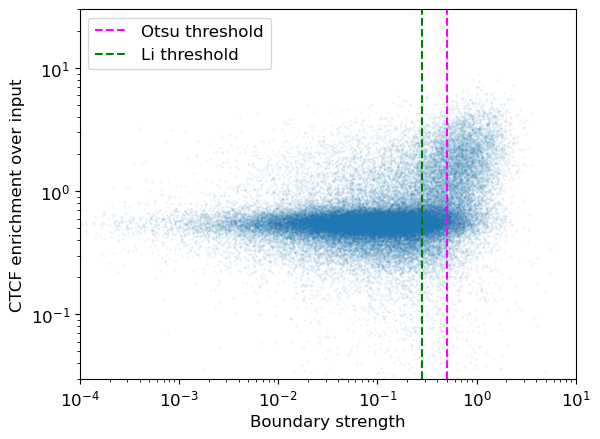

In [46]:
w=windows[0]
f, ax = plt.subplots()
ax.loglog(
    boundaries_1[f'boundary_strength_{w}'],
    ctcf_chip_signal_1,
    'o',
    markersize=1,
    alpha=0.05
);
ax.set(
    xlim=(1e-4,1e1),
    ylim=(3e-2,3e1),
    xlabel='Boundary strength',
    ylabel='CTCF enrichment over input')

ax.axvline(thresholds_otsu_1[w], ls='--', color='magenta', label='Otsu threshold')
ax.axvline(thresholds_li_1[w], ls='--', color='green', label='Li threshold')
ax.legend()

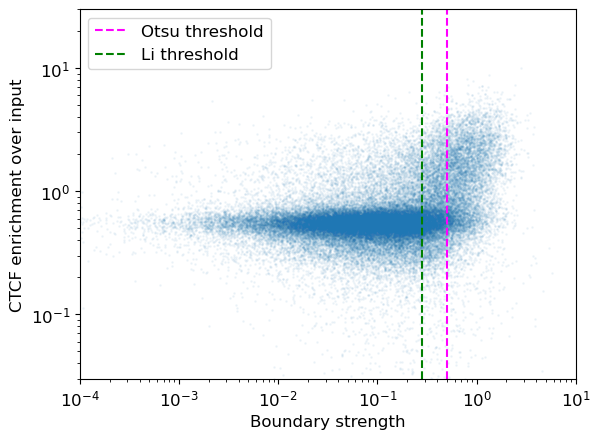

In [48]:
w=windows[0]
f, ax = plt.subplots()
ax.loglog(
    boundaries_2[f'boundary_strength_{w}'],
    ctcf_chip_signal_2,
    'o',
    markersize=1,
    alpha=0.05
);
ax.set(
    xlim=(1e-4,1e1),
    ylim=(3e-2,3e1),
    xlabel='Boundary strength',
    ylabel='CTCF enrichment over input')

ax.axvline(thresholds_otsu_2[w], ls='--', color='magenta', label='Otsu threshold')
ax.axvline(thresholds_li_2[w], ls='--', color='green', label='Li threshold')
ax.legend()